In [ ]:
import os
import cv2
import numpy as np
import pywt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

RAW_DATASET_ROOT = "E:/2025-2026/Project/code1/archive/aptos_sorted"
OUTPUT_DIR = "E:/2025-2026/Project/code1/APTOS_processed"
IMG_SIZE = 224 

CLASSES_MAP = {
    0: "No_DR",
    1: "DR/mild1",
    2: "DR/moderate2",
    3: "DR/severe4",
    4: "DR/proliferative3"
}

os.makedirs(OUTPUT_DIR, exist_ok=True)


def improve_robustness(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img_clahe = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    blur = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=IMG_SIZE / 30)
    img_final = cv2.addWeighted(img_clahe, 4, blur, -4, 128)
    return img_final

def get_wavelet_auxiliary_channels(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    coeffs = pywt.dwt2(gray.astype(np.float32), 'haar')
    LL, (LH, HL, HH) = coeffs
    channels = []
    for subband in [LL, LH, HL, HH]:
        resized = cv2.resize(subband, (IMG_SIZE, IMG_SIZE))
        norm = (resized - np.mean(resized)) / (np.std(resized) + 1e-6)
        norm = (norm - norm.min()) / (norm.max() - norm.min() + 1e-6)
        channels.append(norm)
    return np.stack(channels, axis=-1)

def preprocess_pipeline(path):
    img = cv2.imread(path)
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 10
    if mask.any():
        coords = np.column_stack(np.where(mask))
        ymin, xmin = coords.min(axis=0)
        ymax, xmax = coords.max(axis=0)
        img = img[int(ymin):int(ymax)+1, int(xmin):int(xmax)+1]
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_enhanced = improve_robustness(img)
    wavelet_feats = get_wavelet_auxiliary_channels(img_enhanced)
    
    img_norm = img_enhanced.astype(np.float32) / 255.0
    return np.concatenate([img_norm, wavelet_feats], axis=-1)



def get_all_filepaths():
    all_files = []
    all_labels = []
    for label_idx, folder_path in CLASSES_MAP.items():
        full_path = os.path.join(RAW_DATASET_ROOT, folder_path)
        if not os.path.exists(full_path):
            print(f"Warning: Folder {full_path} not found.")
            continue
        files = [os.path.join(full_path, f) for f in os.listdir(full_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_files.extend(files)
        all_labels.extend([label_idx] * len(files))
    return np.array(all_files), np.array(all_labels)

def process_and_save_group(file_paths, labels, set_name, is_train=False):
    """
    set_name: 'train', 'val', or 'test'
    is_train: If true, oversampling balancing is performed
    """
    final_files = []
    final_labels = []

    if is_train:
        
        unique_labels = np.unique(labels)
        counts = [np.sum(labels == l) for l in unique_labels]
        target_count = max(counts)
        print(f"Balancing training set to {target_count} samples per class...")
        
        for l in unique_labels:
            idx_of_label = np.where(labels == l)[0]
        
            resampled_idx = np.random.choice(idx_of_label, target_count, replace=True)
            for i in resampled_idx:
                final_files.append(file_paths[i])
                final_labels.append(l)
    else:
        final_files = file_paths
        final_labels = labels

    
    X_list, y_list = [], []
    print(f"Processing {set_name} set ({len(final_files)} images)...")
    
    for i in tqdm(range(len(final_files))):
        data = preprocess_pipeline(final_files[i])
        if data is not None:
            
            if is_train and i >= len(file_paths): 
                if np.random.rand() > 0.5: data = np.flip(data, axis=1)

            X_list.append(data)
            y_list.append(final_labels[i])
            
    
    X_arr = np.array(X_list, dtype=np.float32)
    y_arr = np.array(y_list, dtype=np.int32)
    
    y_onehot = np.eye(5)[y_arr]

    np.save(os.path.join(OUTPUT_DIR, f"X_{set_name}.npy"), X_arr)
    np.save(os.path.join(OUTPUT_DIR, f"y_{set_name}.npy"), y_onehot)
    print(f"Successfully saved {set_name} set. Shape: {X_arr.shape}")



if __name__ == "__main__":
    
    paths, labels = get_all_filepaths()
    
    
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        paths, labels, test_size=0.15, stratify=labels, random_state=42
    )
    
    
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, test_size=0.15, stratify=train_val_labels, random_state=42
    )
    
    
    process_and_save_group(train_paths, train_labels, "train", is_train=True)
    process_and_save_group(val_paths, val_labels, "val", is_train=False)
    process_and_save_group(test_paths, test_labels, "test", is_train=False)

    print("\n--- All Done! ---")

Balancing training set to 1304 samples per class...
Processing train set (6520 images)...


100%|██████████| 6520/6520 [28:29<00:00,  3.81it/s]  


Successfully saved train set. Shape: (6520, 224, 224, 7)
Processing val set (467 images)...


100%|██████████| 467/467 [01:33<00:00,  4.98it/s]


Successfully saved val set. Shape: (467, 224, 224, 7)
Processing test set (550 images)...


100%|██████████| 550/550 [01:51<00:00,  4.93it/s]


Successfully saved test set. Shape: (550, 224, 224, 7)

--- All Done! ---



Loading 7-Channel data (RGB + Wavelet)...



[INFO] Beginning training...
Epoch 1/40


408/408 [==============================] - ETA: 0s - loss: 0.2325 - accuracy: 0.3580

d:\anaconda\envs\Project\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


408/408 [==============================] - 650s 2s/step - loss: 0.2325 - accuracy: 0.3580 - val_loss: 0.2091 - val_accuracy: 0.5246 - lr: 1.0000e-04
Epoch 2/40
408/408 [==============================] - 633s 2s/step - loss: 0.1871 - accuracy: 0.4879 - val_loss: 0.1594 - val_accuracy: 0.6445 - lr: 1.0000e-04
Epoch 3/40
408/408 [==============================] - 631s 2s/step - loss: 0.1738 - accuracy: 0.5304 - val_loss: 0.1462 - val_accuracy: 0.6702 - lr: 1.0000e-04
Epoch 4/40
408/408 [==============================] - 626s 2s/step - loss: 0.1675 - accuracy: 0.5497 - val_loss: 0.1445 - val_accuracy: 0.6595 - lr: 1.0000e-04
Epoch 5/40
408/408 [==============================] - 623s 2s/step - loss: 0.1617 - accuracy: 0.5724 - val_loss: 0.1450 - val_accuracy: 0.6381 - lr: 1.0000e-04
Epoch 6/40
408/408 [==============================] - 633s 2s/step - loss: 0.1571 - accuracy: 0.5862 - val_loss: 0.1618 - val_accuracy: 0.5696 - lr: 1.0000e-04
Epoch 7/40
408/408 [==============================]

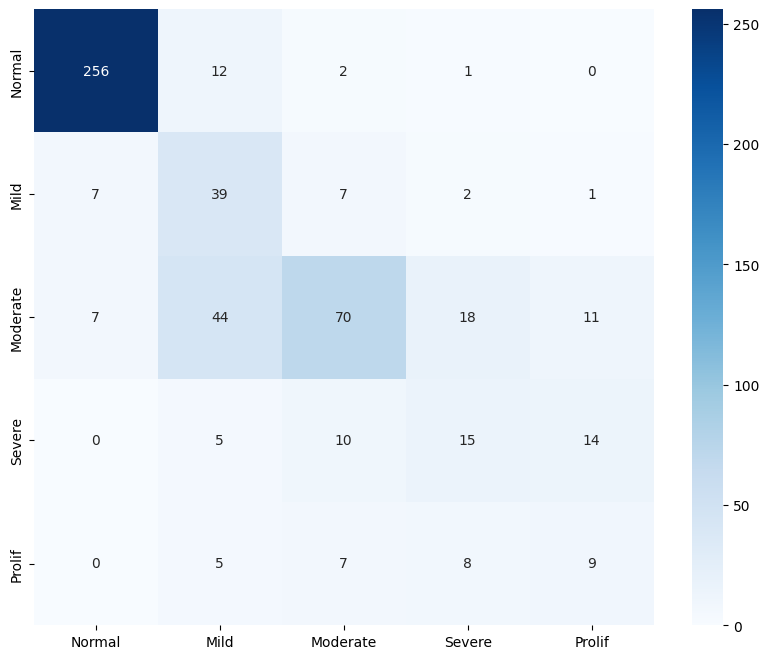

In [ ]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, cohen_kappa_score, 
                             f1_score, roc_auc_score)


DATA_DIR = "E:/2025-2026/Project/code1/APTOS_processed"
SAVE_DIR = "./results_final"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 16  
EPOCHS = 40
LEARNING_RATE = 1e-4

def load_data():
    print("Loading 7-Channel data (RGB + Wavelet)...")
    X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
    y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
    X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
    y_val = np.load(os.path.join(DATA_DIR, "y_val.npy"))
    X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
    y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))
    return X_train, y_train, X_val, y_val, X_test, y_test



def focal_loss_with_smoothing(gamma=2., alpha=0.25, smoothing=0.1):
    
    def loss(y_true, y_pred):
        y_true = y_true * (1.0 - smoothing) + (smoothing / 5.0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * (-y_true * tf.math.log(y_pred)), axis=1)
    return loss

def se_block(x, ratio=8):
    
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.multiply([x, layers.Reshape((1, 1, filters))(se)])

def residual_inception_module(x, filters):
    
    shortcut = layers.Conv2D(filters, 1, padding='same')(x)
    shortcut = layers.BatchNormalization()(shortcut)
    
    
    b1 = layers.SeparableConv2D(filters // 4, 1, padding='same', activation='relu')(x)
    b2 = layers.SeparableConv2D(filters // 4, 3, padding='same', activation='relu')(x)
    b3 = layers.SeparableConv2D(filters // 4, 5, padding='same', activation='relu')(x)
    b4 = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    b4 = layers.Conv2D(filters // 4, 1, padding='same', activation='relu')(b4)
    
    m = layers.Concatenate()([b1, b2, b3, b4])
    m = layers.BatchNormalization()(m)
    return layers.Activation('relu')(layers.add([m, shortcut]))


def build_model():
    inputs = layers.Input(shape=(224, 224, 7))
    
    x = layers.SeparableConv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    
    for f in [64, 128, 256]:
        x = residual_inception_module(x, f)
        x = se_block(x)
        x = layers.MaxPooling2D()(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(5, activation='softmax')(x)
    
    return models.Model(inputs, outputs)



if __name__ == "__main__":
    X_train, y_train, X_val, y_val, X_test, y_test = load_data()
    
    model = build_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=focal_loss_with_smoothing(),
        metrics=['accuracy']
    )

    
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            os.path.join(SAVE_DIR, "best_model.h5"), 
            save_best_only=True, monitor='val_accuracy'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True)
    ]

    print("\n[INFO] Beginning training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks
    )

    # 保存训练历史 CSV
    pd.DataFrame(history.history).to_csv(os.path.join(SAVE_DIR, "training_history.csv"), index=False)
    print(f"\n[SUCCESS] Training history and model saved to {SAVE_DIR}")

    
    print("\n[INFO] Generating test set report...")
    
    
    best_model = models.load_model(
        os.path.join(SAVE_DIR, "best_model.h5"),
        custom_objects={'loss': focal_loss_with_smoothing()}
    )
    
    y_pred_probs = best_model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    f1_m = f1_score(y_true, y_pred, average='macro')
    
    print(f">>> Quadratic Kappa Score: {kappa:.4f}")
    print(f">>> Macro F1-Score: {f1_m:.4f}")

    
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Normal", "Mild", "Moderate", "Severe", "Prolif"],
                yticklabels=["Normal", "Mild", "Moderate", "Severe", "Prolif"])
    plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"))
    print(f"[INFO] Evalution metrics and confusion matrix saved to ")

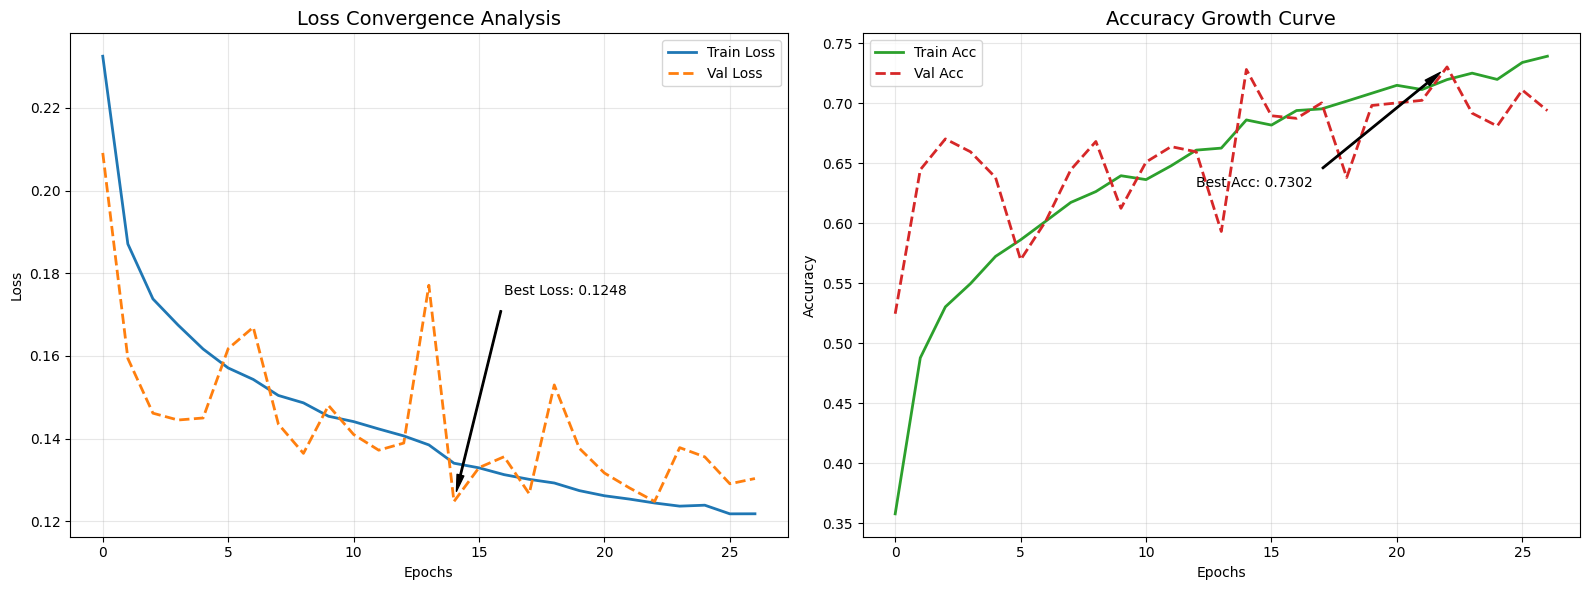

18/18 [==============================] - 17s 907ms/step


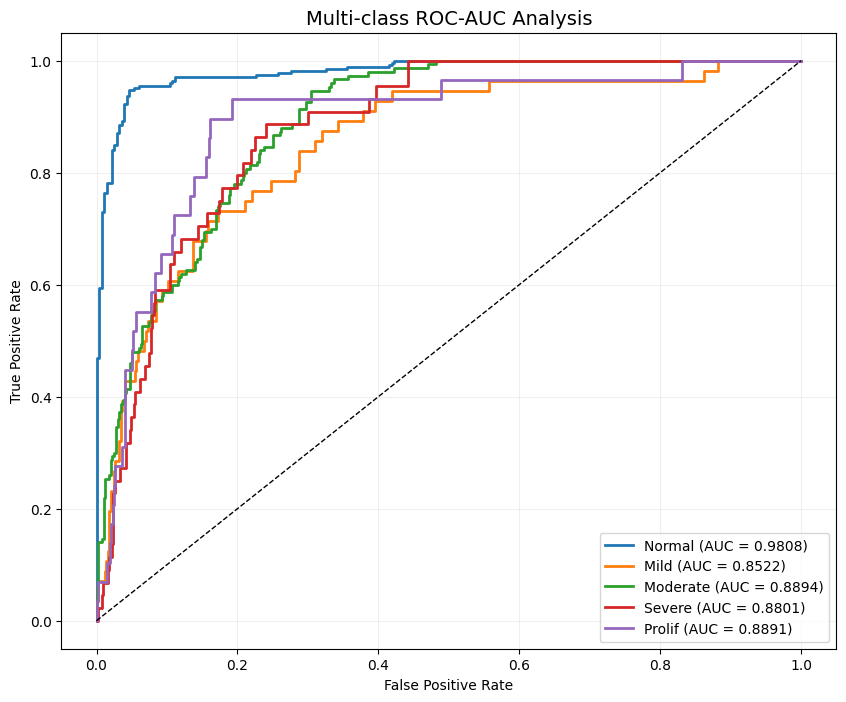

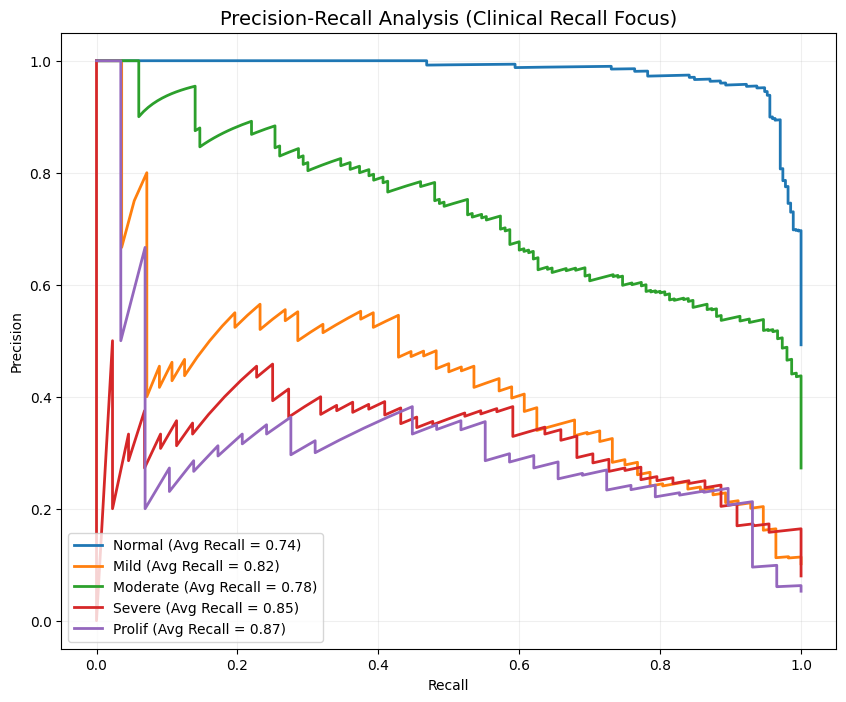

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from tensorflow.keras.models import load_model


SAVE_DIR = "./results_final"
DATA_DIR = "E:/2025-2026/Project/code1/APTOS_processed"
target_names = ["Normal", "Mild", "Moderate", "Severe", "Prolif"]


history_df = pd.read_csv(os.path.join(SAVE_DIR, "training_history.csv"))


def plot_learning_curves(df):
    plt.figure(figsize=(16, 6))
    
    # --- Loss Curve ---
    plt.subplot(1, 2, 1)
    plt.plot(df['loss'], label='Train Loss', color='#1f77b4', lw=2)
    plt.plot(df['val_loss'], label='Val Loss', color='#ff7f0e', lw=2, linestyle='--')
    

    min_val_loss = df['val_loss'].min()
    best_epoch = df['val_loss'].idxmin()
    plt.annotate(f'Best Loss: {min_val_loss:.4f}', 
                 xy=(best_epoch, min_val_loss), 
                 xytext=(best_epoch + 2, min_val_loss + 0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
    
    plt.title('Loss Convergence Analysis', fontsize=14)
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, alpha=0.3)

    
    plt.subplot(1, 2, 2)
    plt.plot(df['accuracy'], label='Train Acc', color='#2ca02c', lw=2)
    plt.plot(df['val_accuracy'], label='Val Acc', color='#d62728', lw=2, linestyle='--')
    
    
    max_val_acc = df['val_accuracy'].max()
    best_acc_epoch = df['val_accuracy'].idxmax()
    plt.annotate(f'Best Acc: {max_val_acc:.4f}', 
                 xy=(best_acc_epoch, max_val_acc), 
                 xytext=(best_acc_epoch - 10, max_val_acc - 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
    
    plt.title('Accuracy Growth Curve', fontsize=14)
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "annotated_learning_curves.png"), dpi=300)
    plt.show()


def plot_advanced_metrics():
    def focal_loss_with_smoothing(gamma=2., alpha=0.25, smoothing=0.1):
        def loss(y_true, y_pred):
            y_true = y_true * (1.0 - smoothing) + (smoothing / 5.0)
            y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
            focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
            return tf.reduce_sum(focal_weight * (-y_true * tf.math.log(y_pred)), axis=1)
        return loss

    X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
    y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))
    
    model = load_model(os.path.join(SAVE_DIR, "best_model.h5"), 
                       custom_objects={'loss': focal_loss_with_smoothing()})
    
    y_score = model.predict(X_test)
    n_classes = 5

    
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{target_names[i]} (AUC = {roc_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title('Multi-class ROC-AUC Analysis', fontsize=14)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.2)
    plt.savefig(os.path.join(SAVE_DIR, "annotated_roc_auc.png"), dpi=300)
    plt.show()

   
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test[:, i], y_score[:, i])
        
        avg_recall = np.mean(recall)
        plt.plot(recall, precision, lw=2, label=f'{target_names[i]} (Avg Recall = {avg_recall:.2f})')
    
    plt.title('Precision-Recall Analysis (Clinical Recall Focus)', fontsize=14)
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.legend(loc="lower left", fontsize=10)
    plt.grid(alpha=0.2)
    plt.savefig(os.path.join(SAVE_DIR, "annotated_pr_recall.png"), dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_learning_curves(history_df)
    plot_advanced_metrics()

In [ ]:
import os
import cv2
import shap
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model




MODEL_PATH = "./results_final/best_model.h5"
DATA_DIR = "E:/2025-2026/Project/code1/APTOS_processed"
SAVE_DIR = "./improved_explainability_outputs"

os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE = 224
N_CLASSES = 5

TARGET_NAMES = ["Normal", "Mild", "Moderate", "Severe", "Prolif"]
FEATURE_NAMES = ["R", "G", "B", "LL", "LH", "HL", "HH"]

BACKGROUND_N = 30     
EVAL_N = 10           
GRADCAM_N = 10        




print("[INFO] Loading model and data...")

# compile=False 可以避免 custom loss 加载问题
model = load_model(MODEL_PATH, compile=False)

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("[INFO] X_train:", X_train.shape)
print("[INFO] X_test :", X_test.shape)




np.random.seed(42)

bg_idx = np.random.choice(len(X_train), min(BACKGROUND_N, len(X_train)), replace=False)
X_bg = X_train[bg_idx]

X_eval = X_test[:EVAL_N]
y_eval = y_test[:EVAL_N]

preds_eval = model.predict(X_eval, verbose=0)
pred_classes = np.argmax(preds_eval, axis=1)
true_classes = np.argmax(y_eval, axis=1)

print("[INFO] Predicted classes:", pred_classes)
print("[INFO] True classes     :", true_classes)




def select_predicted_class_shap(shap_values_all, pred_classes):
    """
    Select SHAP values for each sample's predicted class.

    Compatible with different SHAP versions:
    1. list[class] -> (N, H, W, C)
    2. ndarray -> (N, H, W, C, classes)
    3. ndarray -> (classes, N, H, W, C)
    """

    if isinstance(shap_values_all, list):
        sv_pred = np.stack([
            shap_values_all[int(pred_classes[i])][i]
            for i in range(len(pred_classes))
        ], axis=0)
        return sv_pred

    sv = np.asarray(shap_values_all)

    if sv.ndim == 5:
        # Case 1: (N, H, W, C, classes)
        if sv.shape[0] == len(pred_classes) and sv.shape[-1] == N_CLASSES:
            sv_pred = np.stack([
                sv[i, :, :, :, int(pred_classes[i])]
                for i in range(len(pred_classes))
            ], axis=0)
            return sv_pred

        # Case 2: (classes, N, H, W, C)
        if sv.shape[0] == N_CLASSES and sv.shape[1] == len(pred_classes):
            sv_pred = np.stack([
                sv[int(pred_classes[i]), i, :, :, :]
                for i in range(len(pred_classes))
            ], axis=0)
            return sv_pred

    if sv.ndim == 4:
        # Already selected output
        return sv

    raise ValueError(f"Unsupported SHAP values shape: {sv.shape}")


print("\n[INFO] Building SHAP GradientExplainer...")
explainer = shap.GradientExplainer(model, X_bg)

print("[INFO] Computing SHAP values...")
shap_values_all = explainer.shap_values(X_eval)

sv_pred = select_predicted_class_shap(shap_values_all, pred_classes)

print("[INFO] Selected SHAP shape:", sv_pred.shape)
print("[INFO] SHAP min:", np.min(sv_pred))
print("[INFO] SHAP max:", np.max(sv_pred))
print("[INFO] SHAP abs max:", np.max(np.abs(sv_pred)))



sv_channel_signed = np.sum(sv_pred, axis=(1, 2))


X_channel = np.mean(X_eval, axis=(1, 2))

print("\n[INFO] Channel-level signed SHAP values:")
for i in range(len(X_eval)):
    print(f"Sample {i}, Pred = {TARGET_NAMES[pred_classes[i]]}")
    for name, value in zip(FEATURE_NAMES, sv_channel_signed[i]):
        print(f"  {name}: {value:.6f}")




print("\n[INFO] Saving SHAP summary bar plot...")

plt.figure()
shap.summary_plot(
    sv_channel_signed,
    X_channel,
    feature_names=FEATURE_NAMES,
    plot_type="bar",
    show=False
)
plt.title("Channel-level SHAP Importance")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "shap_summary_bar.png"), dpi=300, bbox_inches="tight")
plt.close()




print("[INFO] Saving SHAP summary dot plot...")

plt.figure()
shap.summary_plot(
    sv_channel_signed,
    X_channel,
    feature_names=FEATURE_NAMES,
    show=False
)
plt.title("Channel-level SHAP Summary")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "shap_summary_dot.png"), dpi=300, bbox_inches="tight")
plt.close()



sample_id = 0
sample_class = int(pred_classes[sample_id])

bg_preds = model.predict(X_bg, verbose=0)
base_value = np.mean(bg_preds[:, sample_class])

print("\n[INFO] Saving SHAP force plot and waterfall plot...")
print("[INFO] Sample ID:", sample_id)
print("[INFO] Explained class:", TARGET_NAMES[sample_class])
print("[INFO] Base value:", base_value)
print("[INFO] Model output:", preds_eval[sample_id, sample_class])
print("[INFO] Base + SHAP sum:", base_value + np.sum(sv_channel_signed[sample_id]))


try:
    shap.force_plot(
        base_value,
        sv_channel_signed[sample_id],
        X_channel[sample_id],
        feature_names=FEATURE_NAMES,
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP Force Plot - {TARGET_NAMES[sample_class]}")
    plt.savefig(os.path.join(SAVE_DIR, "shap_force_sample0.png"), dpi=300, bbox_inches="tight")
    plt.close()
except Exception as e:
    print("[WARNING] Force plot failed:", e)


try:
    shap.plots._waterfall.waterfall_legacy(
        base_value,
        sv_channel_signed[sample_id],
        X_channel[sample_id],
        feature_names=FEATURE_NAMES,
        show=False
    )
    plt.title(f"SHAP Waterfall Plot - {TARGET_NAMES[sample_class]}")
    plt.savefig(os.path.join(SAVE_DIR, "shap_waterfall_sample0.png"), dpi=300, bbox_inches="tight")
    plt.close()
except Exception as e:
    print("[WARNING] Waterfall plot failed:", e)



def channel_ablation_importance(model, X_samples):
    """
    Remove one channel at a time and calculate prediction score drop.
    If removing a channel causes a large drop, that channel is important.
    """

    preds = model.predict(X_samples, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    all_drops = []

    for c in range(7):
        X_masked = X_samples.copy()
        X_masked[:, :, :, c] = 0.0

        masked_preds = model.predict(X_masked, verbose=0)

        drops = []
        for i in range(len(X_samples)):
            cls = pred_classes[i]
            original_score = preds[i, cls]
            masked_score = masked_preds[i, cls]
            drop = original_score - masked_score
            drops.append(drop)

        all_drops.append(drops)

    all_drops = np.array(all_drops).T
    mean_drops = np.mean(all_drops, axis=0)

    return mean_drops, all_drops


print("\n[INFO] Computing channel ablation importance...")

mean_drops, all_drops = channel_ablation_importance(model, X_eval)

print("[INFO] Mean channel score drops:")
for name, value in zip(FEATURE_NAMES, mean_drops):
    print(f"{name}: {value:.6f}")

plt.figure(figsize=(8, 5))
plt.bar(FEATURE_NAMES, mean_drops)
plt.xlabel("Input Channels")
plt.ylabel("Average Prediction Score Drop")
plt.title("Channel Ablation Importance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "channel_ablation_importance.png"), dpi=300)
plt.close()

np.save(os.path.join(SAVE_DIR, "channel_ablation_mean_drops.npy"), mean_drops)
np.save(os.path.join(SAVE_DIR, "channel_ablation_all_drops.npy"), all_drops)



def find_last_conv_layer(model):
    """
    Automatically find the last convolution-like layer.
    This is better than manually using layer name like 'conv2d'.
    """

    conv_layer_types = (
        tf.keras.layers.Conv2D,
        tf.keras.layers.SeparableConv2D,
        tf.keras.layers.DepthwiseConv2D
    )

    for layer in reversed(model.layers):
        if isinstance(layer, conv_layer_types):
            return layer.name

    # fallback: any 4D output layer
    for layer in reversed(model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except Exception:
            pass

    raise ValueError("No convolutional layer found.")


def make_gradcam_heatmap(img, model, layer_name, class_idx=None):
    """
    Generate Grad-CAM heatmap for one image.
    """

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    img_tensor = tf.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)

        if class_idx is None:
            class_idx = tf.argmax(predictions[0])

        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


print("\n[INFO] Generating Grad-CAM images...")

last_conv_layer_name = find_last_conv_layer(model)
print("[INFO] Selected Grad-CAM layer:", last_conv_layer_name)

gradcam_dir = os.path.join(SAVE_DIR, "gradcam")
os.makedirs(gradcam_dir, exist_ok=True)

for i in range(min(GRADCAM_N, len(X_eval))):
    img = X_eval[i]
    rgb = img[:, :, :3]

    pred_class = int(pred_classes[i])

    heatmap = make_gradcam_heatmap(
        img=img,
        model=model,
        layer_name=last_conv_layer_name,
        class_idx=pred_class
    )

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    rgb_uint8 = np.uint8(np.clip(rgb * 255.0, 0, 255))

    
    rgb_bgr = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2BGR)

    overlay = cv2.addWeighted(rgb_bgr, 0.6, heatmap_color, 0.4, 0)

    save_path = os.path.join(
        gradcam_dir,
        f"gradcam_sample_{i}_true_{TARGET_NAMES[true_classes[i]]}_pred_{TARGET_NAMES[pred_class]}.png"
    )

    cv2.imwrite(save_path, overlay)

print("\n[SUCCESS] Improved explainability analysis completed.")
print("[SUCCESS] Results saved to:", SAVE_DIR)


[INFO] Loading model and data...


[INFO] X_train: (6520, 224, 224, 7)
[INFO] X_test : (550, 224, 224, 7)
[INFO] Predicted classes: [1 4 0 3 0 0 3 1 4 0]
[INFO] True classes     : [1 3 0 2 0 0 2 1 3 0]

[INFO] Building SHAP GradientExplainer...
[INFO] Computing SHAP values...


d:\anaconda\envs\Project\lib\site-packages\keras\src\backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


[INFO] Selected SHAP shape: (10, 224, 224, 7)
[INFO] SHAP min: -0.0027563516050577164
[INFO] SHAP max: 0.0033783114049583673
[INFO] SHAP abs max: 0.0033783114049583673

[INFO] Channel-level signed SHAP values:
Sample 0, Pred = Mild
  R: 0.070355
  G: 0.096823
  B: 0.070639
  LL: 0.003403
  LH: 0.020458
  HL: 0.042355
  HH: -0.014377
Sample 1, Pred = Prolif
  R: -0.341530
  G: 0.328971
  B: -0.010669
  LL: 0.166378
  LH: 0.000156
  HL: 0.013037
  HH: 0.009741
Sample 2, Pred = Normal
  R: 0.271349
  G: 0.091068
  B: 0.161836
  LL: 0.076481
  LH: -0.011840
  HL: 0.025169
  HH: 0.108731
Sample 3, Pred = Severe
  R: 0.043954
  G: 0.357795
  B: -0.226216
  LL: 0.019946
  LH: 0.011459
  HL: 0.030154
  HH: 0.004529
Sample 4, Pred = Normal
  R: -0.075137
  G: 0.229847
  B: 0.302275
  LL: 0.132494
  LH: 0.019220
  HL: 0.073206
  HH: 0.037194
Sample 5, Pred = Normal
  R: 0.144483
  G: -0.016549
  B: 0.302060
  LL: 0.127143
  LH: 0.014034
  HL: 0.060432
  HH: 0.090922
Sample 6, Pred = Severe
  R: 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_53132\3666318057.py:157: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


[INFO] Saving SHAP summary dot plot...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_53132\3666318057.py:177: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(



[INFO] Saving SHAP force plot and waterfall plot...
[INFO] Sample ID: 0
[INFO] Explained class: Mild
[INFO] Base value: 0.26552114
[INFO] Model output: 0.5956555
[INFO] Base + SHAP sum: 0.555179133643636

[INFO] Computing channel ablation importance...
[INFO] Mean channel score drops:
R: 0.458519
G: 0.210758
B: 0.338540
LL: 0.314743
LH: 0.184150
HL: 0.366072
HH: 0.555381

[INFO] Generating Grad-CAM images...
[INFO] Selected Grad-CAM layer: conv2d_4

[SUCCESS] Improved explainability analysis completed.
[SUCCESS] Results saved to: ./improved_explainability_outputs


In [ ]:
import os
import cv2
import numpy as np
import pywt
from tqdm import tqdm


RAW_DATASET2_DIR = "E:/2025-2026/Project/code1/dataset" 
OUTPUT_DIR2 = "E:/2025-2026/Project/code1/Dataset2_processed"
IMG_SIZE = 224


CLASSES_MAP = {
    "normal": 0,                
    "diabetic_retinopathy": 3   
}

os.makedirs(OUTPUT_DIR2, exist_ok=True)



def improve_robustness(img):
    
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img_clahe = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    
    blur = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=IMG_SIZE / 30)
    img_final = cv2.addWeighted(img_clahe, 4, blur, -4, 128)
    return img_final

def get_wavelet_channels(img):
    
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    coeffs = pywt.dwt2(gray.astype(np.float32), 'haar')
    LL, (LH, HL, HH) = coeffs
    channels = []
    for subband in [LL, LH, HL, HH]:
        resized = cv2.resize(subband, (IMG_SIZE, IMG_SIZE))
       
        norm = (resized - resized.min()) / (resized.max() - resized.min() + 1e-6)
        channels.append(norm)
    return np.stack(channels, axis=-1)

def preprocess_image(path):
    
    img = cv2.imread(path)
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
  
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 10
    if mask.any():
        coords = np.column_stack(np.where(mask))
        ymin, xmin = coords.min(axis=0); ymax, xmax = coords.max(axis=0)
        img = img[ymin:ymax+1, xmin:xmax+1]
    
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_enhanced = improve_robustness(img)
    
    
    wavelet_feats = get_wavelet_channels(img_enhanced)
    
    
    img_norm = img_enhanced.astype(np.float32) / 255.0
    return np.concatenate([img_norm, wavelet_feats], axis=-1)


def run_external_prep():
    X_ext, y_ext = [], []
    
    for folder_name, label_val in CLASSES_MAP.items():
        folder_path = os.path.join(RAW_DATASET2_DIR, folder_name)
        if not os.path.exists(folder_path):
            print(f"[Warning] directory cannot be found: {folder_path}")
            continue
            
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"Loading {folder_name} (label: {label_val})，total {len(files)} pictures...")
        
        for f in tqdm(files):
            img_p = os.path.join(folder_path, f)
            data = preprocess_image(img_p)
            if data is not None:
                X_ext.append(data)
                y_ext.append(label_val)

    X_ext = np.array(X_ext, dtype=np.float32)
    y_ext = np.array(y_ext)
    
    # 保存结果
    np.save(os.path.join(OUTPUT_DIR2, "X_dataset2.npy"), X_ext)
    np.save(os.path.join(OUTPUT_DIR2, "y_dataset2.npy"), y_ext)
    print(f"\n[Success] Data set 2 preprocessing completed，total {len(X_ext)}")
    print(f"file save to: {OUTPUT_DIR2}")

if __name__ == "__main__":
    run_external_prep()

正在处理 normal (标签: 0)，共 1074 张图片...


100%|██████████| 1074/1074 [00:28<00:00, 37.46it/s]


正在处理 diabetic_retinopathy (标签: 3)，共 1098 张图片...


100%|██████████| 1098/1098 [00:21<00:00, 51.52it/s]



[Success] 数据集 2 预处理完成，共 2172 样本。
file save to: E:/2025-2026/Project/code1/Dataset2_processed



[INFO] Loading model and Dataset 2...


[INFO] Dataset 2 size: (2172, 224, 224, 7)
[INFO] Running inference...
136/136 [==============================] - 81s 569ms/step

Binary Accuracy: 0.5327
F1 Score: 0.2014


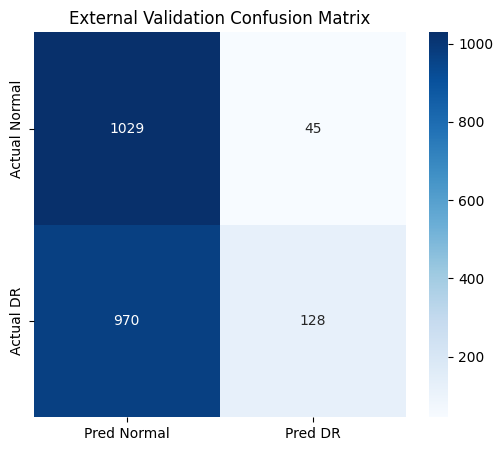

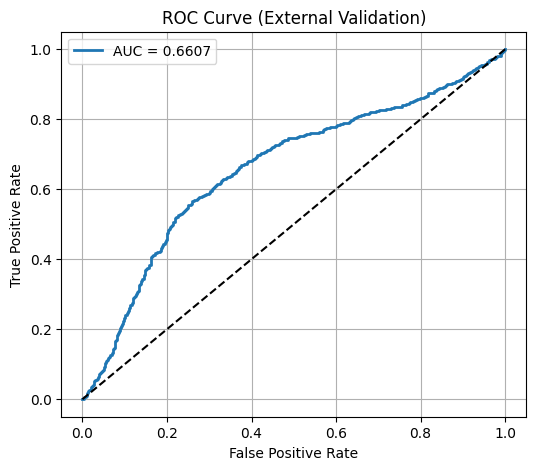

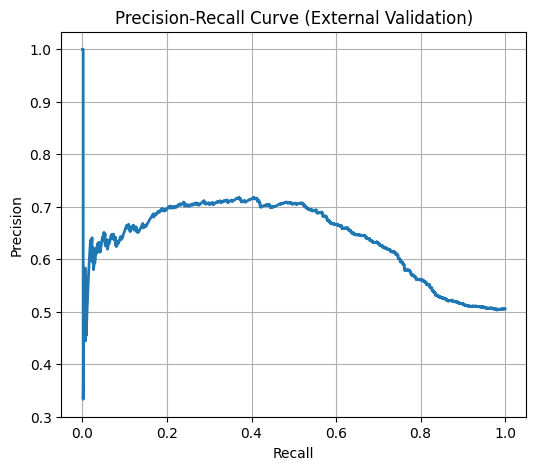

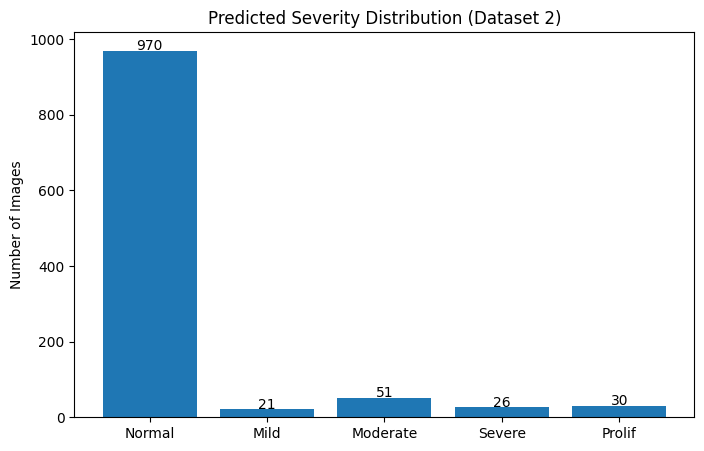


[SUCCESS] External validation completed and all results saved.


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    roc_curve, auc, precision_recall_curve, roc_auc_score
)


DATA_DIR2 = "E:/2025-2026/Project/code1/Dataset2_processed"
MODEL_PATH = "./results_final/best_model.h5"
SAVE_DIR = "./results_external_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)


def focal_loss_with_smoothing(gamma=2., alpha=0.25, smoothing=0.1):
    def loss(y_true, y_pred):
        y_true = y_true * (1.0 - smoothing) + (smoothing / 5.0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * (-y_true * tf.math.log(y_pred)), axis=1)
    return loss


print("[INFO] Loading model and Dataset 2...")
model = load_model(MODEL_PATH, custom_objects={'loss': focal_loss_with_smoothing()})

X_ext = np.load(os.path.join(DATA_DIR2, "X_dataset2.npy"))
y_ext_raw = np.load(os.path.join(DATA_DIR2, "y_dataset2.npy"))  # 0=Normal, 3=DR

print(f"[INFO] Dataset 2 size: {X_ext.shape}")


print("[INFO] Running inference...")
y_pred_probs = model.predict(X_ext, batch_size=16)
y_pred_classes = np.argmax(y_pred_probs, axis=1)


y_true_bin = (y_ext_raw > 0).astype(int)
y_pred_bin = (y_pred_classes > 0).astype(int)

bin_acc = accuracy_score(y_true_bin, y_pred_bin)
f1 = f1_score(y_true_bin, y_pred_bin)

print("\n" + "="*40)
print(f"Binary Accuracy: {bin_acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("="*40)


cm = confusion_matrix(y_true_bin, y_pred_bin)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred Normal", "Pred DR"],
            yticklabels=["Actual Normal", "Actual DR"])
plt.title("External Validation Confusion Matrix")
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=300)
plt.show()


y_score_bin = np.max(y_pred_probs[:, 1:], axis=1)

fpr, tpr, _ = roc_curve(y_true_bin, y_score_bin)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (External Validation)")
plt.legend()
plt.grid()
plt.savefig(os.path.join(SAVE_DIR, "roc_curve.png"), dpi=300)
plt.show()


precision, recall, _ = precision_recall_curve(y_true_bin, y_score_bin)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (External Validation)")
plt.grid()
plt.savefig(os.path.join(SAVE_DIR, "pr_curve.png"), dpi=300)
plt.show()


target_names = ["Normal", "Mild", "Moderate", "Severe", "Prolif"]

dr_indices = np.where(y_ext_raw > 0)[0]
dr_predictions = y_pred_classes[dr_indices]

levels = [0,1,2,3,4]
counts = [np.sum(dr_predictions == i) for i in levels]

plt.figure(figsize=(8,5))
bars = plt.bar(target_names, counts)
plt.title("Predicted Severity Distribution (Dataset 2)")
plt.ylabel("Number of Images")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+2,
             int(bar.get_height()),
             ha='center')

plt.savefig(os.path.join(SAVE_DIR, "severity_distribution.png"), dpi=300)
plt.show()


np.save(os.path.join(SAVE_DIR, "y_pred_probs.npy"), y_pred_probs)
np.save(os.path.join(SAVE_DIR, "y_pred_classes.npy"), y_pred_classes)
np.save(os.path.join(SAVE_DIR, "y_true.npy"), y_ext_raw)
np.save(os.path.join(SAVE_DIR, "confusion_matrix.npy"), cm)
np.save(os.path.join(SAVE_DIR, "fpr.npy"), fpr)
np.save(os.path.join(SAVE_DIR, "tpr.npy"), tpr)
np.save(os.path.join(SAVE_DIR, "precision.npy"), precision)
np.save(os.path.join(SAVE_DIR, "recall.npy"), recall)

# 保存指标
with open(os.path.join(SAVE_DIR, "metrics.txt"), "w") as f:
    f.write(f"Binary Accuracy: {bin_acc:.4f}\n")
    f.write(f"F1 Score: {f1:.4f}\n")
    f.write(f"AUC: {roc_auc:.4f}\n")

print("\n[SUCCESS] External validation completed and all results saved.")

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model


MODEL_PATH = "./results_final/best_model.h5"
DATA_DIR = "E:/2025-2026/Project/code1/APTOS_processed"
SAVE_DIR = "./gradcam_outputs"

os.makedirs(SAVE_DIR, exist_ok=True)


model = load_model(MODEL_PATH, compile=False)

X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("Loaded:", X_test.shape)


last_conv_layer_name = "conv2d" 


def gradcam(img, model, layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    img_tensor = tf.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]

    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


for i in range(len(X_test)):

    img = X_test[i]
    rgb = img[:, :, :3]

    heatmap = gradcam(img, model, last_conv_layer_name)

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    rgb_uint8 = (rgb * 255).astype(np.uint8)

    overlay = cv2.addWeighted(rgb_uint8, 0.6, heatmap, 0.4, 0)

    save_path = os.path.join(SAVE_DIR, f"gradcam_{i}.png")
    cv2.imwrite(save_path, overlay)

    if i % 50 == 0:
        print(f"Processed {i}/{len(X_test)}")

print("Done. Saved to:", SAVE_DIR)

Loaded: (550, 224, 224, 7)
Processed 0/550
Processed 50/550
Processed 100/550
Processed 150/550
Processed 200/550
Processed 250/550
Processed 300/550
Processed 350/550
Processed 400/550
Processed 450/550
Processed 500/550
Done. Saved to: ./gradcam_outputs


Basline CNN

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import pywt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score


ROOT = "E:/2025-2026/Project/code1/archive/aptos_sorted"
IMG_SIZE = 224


def load_data_rgb():
    X, y = [], []

    for folder in os.listdir(ROOT):
        path = os.path.join(ROOT, folder)

        if folder == "NO_DR":
            label = 0
            files = os.listdir(path)

            for f in files:
                img = cv2.imread(os.path.join(path, f))
                if img is None: continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
                img = img.astype(np.float32)/255.0

                X.append(img)
                y.append(label)

        elif folder == "DR":
            mapping = {
                "Mild1":1,
                "Moderate2":2,
                "Severe4":3,
                "Proliferative3":4
            }

            for sub in mapping:
                sub_path = os.path.join(path, sub)
                for f in os.listdir(sub_path):
                    img = cv2.imread(os.path.join(sub_path,f))
                    if img is None: continue

                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
                    img = img.astype(np.float32)/255.0

                    X.append(img)
                    y.append(mapping[sub])

    return np.array(X), tf.keras.utils.to_categorical(y,5)

# =========================
# Model
# =========================
def build_baseline():
    inputs = tf.keras.Input((224,224,3))

    x = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256,activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(5,activation='softmax')(x)

    return tf.keras.Model(inputs,outputs)

# =========================
# Train
# =========================
X,y = load_data_rgb()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = build_baseline()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=30,batch_size=16,validation_split=0.1)

pred = model.predict(X_test)
y_pred = np.argmax(pred,1)
y_true = np.argmax(y_test,1)

print("Baseline CNN")
print("Acc:",accuracy_score(y_true,y_pred))
print("F1:",f1_score(y_true,y_pred,average='macro'))
print("Kappa:",cohen_kappa_score(y_true,y_pred,weights='quadratic'))


Epoch 1/30
165/165 [==============================] - 30s 172ms/step - loss: 1.2165 - accuracy: 0.5231 - val_loss: 0.9925 - val_accuracy: 0.6348
Epoch 2/30
165/165 [==============================] - 27s 163ms/step - loss: 0.8901 - accuracy: 0.6988 - val_loss: 0.8675 - val_accuracy: 0.7133
Epoch 3/30
165/165 [==============================] - 27s 162ms/step - loss: 0.8330 - accuracy: 0.7147 - val_loss: 0.8094 - val_accuracy: 0.7031
Epoch 4/30
165/165 [==============================] - 27s 161ms/step - loss: 0.8217 - accuracy: 0.7170 - val_loss: 0.8149 - val_accuracy: 0.7235
Epoch 5/30
165/165 [==============================] - 27s 163ms/step - loss: 0.8065 - accuracy: 0.7185 - val_loss: 0.7835 - val_accuracy: 0.7235
Epoch 6/30
165/165 [==============================] - 27s 162ms/step - loss: 0.8079 - accuracy: 0.7174 - val_loss: 0.8363 - val_accuracy: 0.6997
Epoch 7/30
165/165 [==============================] - 27s 163ms/step - loss: 0.8116 - accuracy: 0.7147 - val_loss: 0.8152 - val_a

Basline+CLAHE

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score


ROOT = "E:/2025-2026/Project/code1/archive/aptos_sorted"
IMG_SIZE = 224


def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    return img


def load_data_clahe():
    X, y = [], []

    for folder in os.listdir(ROOT):
        path = os.path.join(ROOT, folder)

        # ================= NO_DR =================
        if folder == "NO_DR":
            label = 0

            for f in os.listdir(path):
                img = cv2.imread(os.path.join(path, f))
                if img is None:
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                
                img = apply_clahe(img)

                img = img.astype(np.float32) / 255.0

                X.append(img)
                y.append(label)

        # ================= DR =================
        elif folder == "DR":
            mapping = {
                "Mild1": 1,
                "Moderate2": 2,
                "Severe4": 3,
                "Proliferative3": 4
            }

            for sub in mapping:
                sub_path = os.path.join(path, sub)

                for f in os.listdir(sub_path):
                    img = cv2.imread(os.path.join(sub_path, f))
                    if img is None:
                        continue

                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    # ⭐ CLAHE only
                    img = apply_clahe(img)

                    img = img.astype(np.float32) / 255.0

                    X.append(img)
                    y.append(mapping[sub])

    return np.array(X), tf.keras.utils.to_categorical(y, 5)


def build_model():
    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(5, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)


X, y = load_data_clahe()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.1
)


pred = model.predict(X_test)

y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n===== CLAHE CNN Results =====")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
print("Kappa:", cohen_kappa_score(y_true, y_pred, weights='quadratic'))

Epoch 1/30
165/165 [==============================] - 34s 189ms/step - loss: 1.3700 - accuracy: 0.4837 - val_loss: 1.3668 - val_accuracy: 0.4266
Epoch 2/30
165/165 [==============================] - 27s 161ms/step - loss: 1.3068 - accuracy: 0.5004 - val_loss: 1.3532 - val_accuracy: 0.4266
Epoch 3/30
165/165 [==============================] - 27s 161ms/step - loss: 1.2751 - accuracy: 0.5008 - val_loss: 1.3131 - val_accuracy: 0.4266
Epoch 4/30
165/165 [==============================] - 27s 162ms/step - loss: 1.2262 - accuracy: 0.5087 - val_loss: 1.2975 - val_accuracy: 0.4403
Epoch 5/30
165/165 [==============================] - 27s 161ms/step - loss: 1.2072 - accuracy: 0.5102 - val_loss: 1.2831 - val_accuracy: 0.4403
Epoch 6/30
165/165 [==============================] - 27s 162ms/step - loss: 1.1903 - accuracy: 0.5140 - val_loss: 1.2685 - val_accuracy: 0.4403
Epoch 7/30
165/165 [==============================] - 27s 161ms/step - loss: 1.1642 - accuracy: 0.5372 - val_loss: 1.2294 - val_ac

Basline+CLAHE+Wavelet

In [ ]:
import os
import cv2
import numpy as np
import pywt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score


ROOT = "E:/2025-2026/Project/code1/archive/aptos_sorted"
IMG_SIZE = 224


def get_wavelet(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    coeffs = pywt.dwt2(gray.astype(np.float32), 'haar')
    LL, (LH, HL, HH) = coeffs

    channels = []
    for band in [LL, LH, HL, HH]:
        band = cv2.resize(band, (IMG_SIZE, IMG_SIZE))
        band = (band - band.min()) / (band.max() - band.min() + 1e-6)
        channels.append(band)

    return np.stack(channels, axis=-1)


def load_wavelet_dataset():
    X, y = [], []

    for folder in os.listdir(ROOT):
        path = os.path.join(ROOT, folder)

        # ================= NO_DR =================
        if folder == "NO_DR":
            label = 0

            for f in os.listdir(path):
                img = cv2.imread(os.path.join(path, f))
                if img is None:
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                wave = get_wavelet(img)

                rgb = img.astype(np.float32) / 255.0

                X.append(np.concatenate([rgb, wave], axis=-1))
                y.append(label)

        # ================= DR =================
        elif folder == "DR":
            mapping = {
                "Mild1": 1,
                "Moderate2": 2,
                "Severe4": 3,
                "Proliferative3": 4
            }

            for sub in mapping:
                sub_path = os.path.join(path, sub)

                for f in os.listdir(sub_path):
                    img = cv2.imread(os.path.join(sub_path, f))
                    if img is None:
                        continue

                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    wave = get_wavelet(img)
                    rgb = img.astype(np.float32) / 255.0

                    X.append(np.concatenate([rgb, wave], axis=-1))
                    y.append(mapping[sub])

    return np.array(X), tf.keras.utils.to_categorical(y, 5)


def build_wavelet_model():
    inputs = tf.keras.Input(shape=(224, 224, 7))

    x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(5, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)


X, y = load_wavelet_dataset()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)


model = build_wavelet_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.1
)


pred = model.predict(X_test)

y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n===== Wavelet CNN Results =====")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
print("Kappa:", cohen_kappa_score(y_true, y_pred, weights='quadratic'))

Epoch 1/30
165/165 [==============================] - 39s 193ms/step - loss: 1.3379 - accuracy: 0.4920 - val_loss: 1.3375 - val_accuracy: 0.4266
Epoch 2/30
165/165 [==============================] - 28s 171ms/step - loss: 1.2351 - accuracy: 0.5129 - val_loss: 1.2634 - val_accuracy: 0.5154
Epoch 3/30
165/165 [==============================] - 27s 164ms/step - loss: 1.1637 - accuracy: 0.5755 - val_loss: 1.1974 - val_accuracy: 0.5495
Epoch 4/30
165/165 [==============================] - 27s 164ms/step - loss: 1.1148 - accuracy: 0.5945 - val_loss: 1.1535 - val_accuracy: 0.5904
Epoch 5/30
165/165 [==============================] - 27s 164ms/step - loss: 1.0779 - accuracy: 0.6051 - val_loss: 1.1382 - val_accuracy: 0.5734
Epoch 6/30
165/165 [==============================] - 27s 163ms/step - loss: 1.0548 - accuracy: 0.6104 - val_loss: 1.1223 - val_accuracy: 0.5768
Epoch 7/30
165/165 [==============================] - 27s 164ms/step - loss: 1.0453 - accuracy: 0.6222 - val_loss: 1.0888 - val_ac